# Testing the CW deterministic model

There are a few things to test:

1) The CW model agrees with standard models (e.g. Enterprise).

2) The CW model works in single precision.

3) The CW model is represented accurately in the Fourier basis.

We run this notebook in `float64` precision first to verify our `float32` agrees with established models. Then we change to `float32` and verify our model is numerically stable.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr

import pickle

import matplotlib.pyplot as plt
import corner

from enterprise_extensions.deterministic import cw_delay

import prometheus.deterministic as det
from prometheus.deterministic_models import DeterministicModel
from prometheus import utilities as utils

%load_ext autoreload
%autoreload 2

libstempo not installed. PINT or libstempo are required to use par and tim files.


In [2]:
# load the NG15 data to get example pulsar positions, distances, etc.
with open('../data/NG15/data.pkl', 'rb') as fp:
    NG15_data = pickle.load(fp)
data_dict = NG15_data.per_psr_data_dict

# PTA attributes
psr_names = NG15_data.psr_names
npsrs = NG15_data.npsrs
psr_dists_measured = NG15_data.psr_dists_measured
psr_dists_std = NG15_data.psr_dists_std
psrpos = NG15_data.psrpos

# some random TOAs to evaluate CW model over
toas = jnp.array([jnp.linspace(utils.tref, utils.tref + 15. * utils.year, 122)
                  for _ in range(npsrs)])

In [3]:
# CW parameter bounds
cw_source_mins = jnp.array([7., -8.7, -1., 0, -18., -1., 0., 0.])
cw_source_maxs = jnp.array([10., -7.4, 1., jnp.pi, -12., 1., 2. * jnp.pi, 2. * jnp.pi])
cw_parameter_bounds = jnp.vstack((cw_source_mins, cw_source_maxs)).T

cw_model = DeterministicModel(name='cw_evolve',
                              data=NG15_data,
                              get_delays_func=det.cw_delay_evolve_float32,
                              parameter_bounds=cw_parameter_bounds)

# example CW parameters
cw_source_params = jnp.array([7.7, -8.4, 0.8, 0., -14., 0., 0., 0.])

# calculate pulsar phase from other parameters for consistent injection
psr_phases = jnp.array([det.get_psr_phase(cw_source_params, pos, dist)
                        for pos, dist in zip(psrpos, psr_dists_measured)])

## Compare CW model with Enterprise

In [4]:
# Enterprise uses weird parameter ordering, so here's a wrapper
def get_ent_cw_delay(toas, psrpos, cw_source_params, psr_phases, psr_dists):

    ent_cw_delays = np.zeros_like(toas)

    for i in range(npsrs):
        psr_dist_standardized = (psr_dists[i] - psr_dists_measured[i]) / psr_dists_std[i]
        ent_cw_delays[i] = cw_delay(toas=toas[i],
                      pos=psrpos[i],
                      pdist=(psr_dists_measured[i], psr_dists_std[i]),
                      cos_gwtheta=cw_source_params[-3],
                      gwphi=cw_source_params[-2],
                      cos_inc=cw_source_params[2],
                      log10_mc=cw_source_params[0],
                      log10_fgw=cw_source_params[1],
                      log10_h=cw_source_params[4],
                      phase0=cw_source_params[-1],
                      psi=cw_source_params[3],
                      psrTerm=True,
                      p_dist=psr_dist_standardized,
                      p_phase=psr_phases[i],
                      evolve=True,
                      tref=utils.tref,
                      )
    return ent_cw_delays * utils.renorm

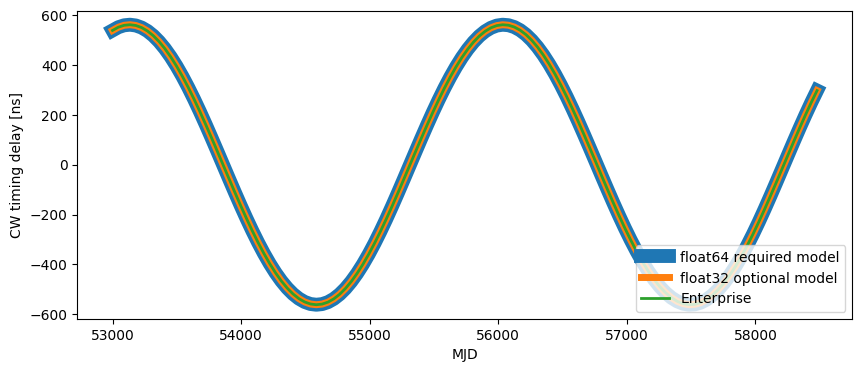

In [6]:
# plot timing delay from CW for random parameters in random pulsar 
psr_ndx = 55
cw_delays = det.cw_delay_evolve_float64(toas, psrpos, cw_source_params, psr_phases, psr_dists_measured)[psr_ndx]
cw_delays32 = cw_model.get_delays_func(toas, psrpos, cw_source_params, psr_phases, psr_dists_measured)[psr_ndx]
ent_delays = get_ent_cw_delay(toas, psrpos, cw_source_params, psr_phases, psr_dists_measured)[psr_ndx]
plt.figure(figsize=(10, 4))
plt.plot(toas[psr_ndx] / utils.day, cw_delays, color='C0',
         label='float64 required model', lw=10)
plt.plot(toas[psr_ndx] / utils.day, cw_delays32, color='C1',
         label='float32 optional model', lw=5)
plt.plot(toas[psr_ndx] / utils.day, ent_delays, color='C2',
         label='Enterprise', lw=2)
plt.legend(loc='lower right')
plt.xlabel('MJD')
plt.ylabel('CW timing delay [ns]')
plt.show()

In [7]:
# compute percent error of float32 model from Enterprise reference
num_evals = 1000

# random CW parameters
random_cw_params = jr.uniform(key=jr.key(1154),
                              shape=(num_evals, cw_source_mins.shape[0]),
                              minval=cw_source_mins,
                              maxval=cw_source_maxs)
random_psr_dists_standard = jr.normal(key=jr.key(2354),
                                      shape=(num_evals, npsrs))
random_psr_dists = (psr_dists_measured
                    + random_psr_dists_standard * psr_dists_std)
get_phases_across_psrs = jax.vmap(lambda x, y, z: det.get_psr_phase(x, y, z), in_axes=(None, 0, 0))
random_psr_phases = jax.vmap(lambda x, y, z: get_phases_across_psrs(x, y, z),
                             in_axes=(0, None, 0))(random_cw_params, psrpos, random_psr_dists)

# loop through random samples
relative_errors = np.zeros((num_evals, npsrs))
for i in range(num_evals):
    print(f'{np.round(i / num_evals * 100, 3)}%', end='\r')
    ent_cw_delays = get_ent_cw_delay(toas, psrpos, random_cw_params[i],
                                     random_psr_phases[i], random_psr_dists[i])
    cw_delays32 = cw_model.get_delays_func(toas, psrpos, random_cw_params[i],
                                              random_psr_phases[i], random_psr_dists[i])
    rel_err = np.sum(np.abs(ent_cw_delays - cw_delays32), axis=1) / np.sum(np.abs(ent_cw_delays), axis=1)
    relative_errors[i] = rel_err
relative_errors_flat = relative_errors.flatten() # flatten across pulsars
print('100.0%')

100.0%


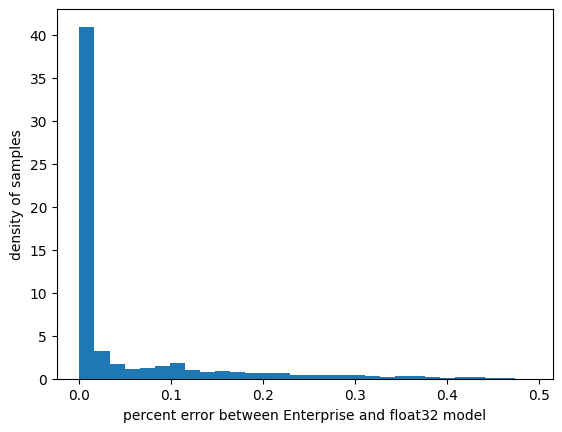

In [8]:
# check distribution of percent errors
percent_errors = relative_errors_flat * 100
plt.hist(percent_errors, density=True, bins=30)
plt.xlabel('percent error between Enterprise and float32 model')
plt.ylabel('density of samples')
plt.show()

[  9.1424029   -7.40168088   0.98118539   1.63968644 -17.50934694
  -0.9837653    1.60631096   5.54596587]


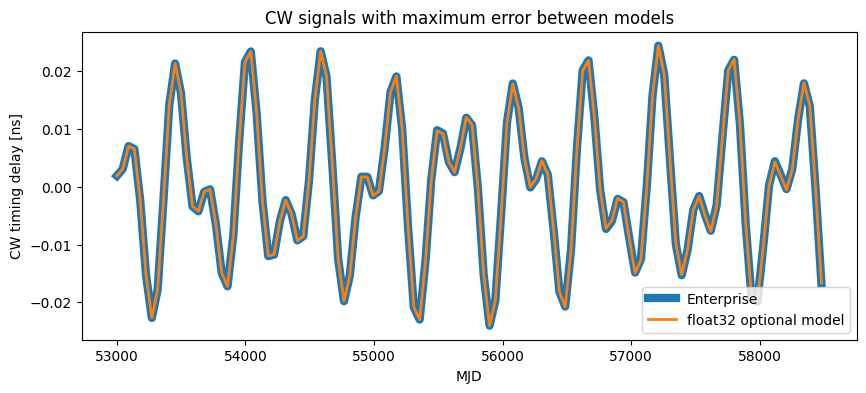

In [9]:
# plot signals with maximum error
max_err_ndx = np.unravel_index(np.argmax(relative_errors), relative_errors.shape)
max_err_sample, max_err_psr = max_err_ndx

max_err_cw_params = random_cw_params[max_err_sample]
max_err_psr_dists = random_psr_dists[max_err_sample]
max_err_psr_phases = random_psr_phases[max_err_sample]
max_err_ent_cw_delay = get_ent_cw_delay(toas, psrpos, max_err_cw_params,
                                        max_err_psr_phases, max_err_psr_dists)[max_err_psr]
max_err_cw_delay32 = det.cw_delay_evolve_float32(toas, psrpos, max_err_cw_params,
                                                 max_err_psr_phases, max_err_psr_dists)[max_err_psr]

print(max_err_cw_params)

plt.figure(figsize=(10, 4))
plt.plot(toas[psr_ndx] / utils.day, max_err_ent_cw_delay, color='C0',
         label='Enterprise', lw=6)
plt.plot(toas[psr_ndx] / utils.day, max_err_cw_delay32, color='C1',
         label='float32 optional model', lw=2)
plt.legend(loc='lower right')
plt.xlabel('MJD')
plt.ylabel('CW timing delay [ns]')
plt.title('CW signals with maximum error between models')
plt.show()

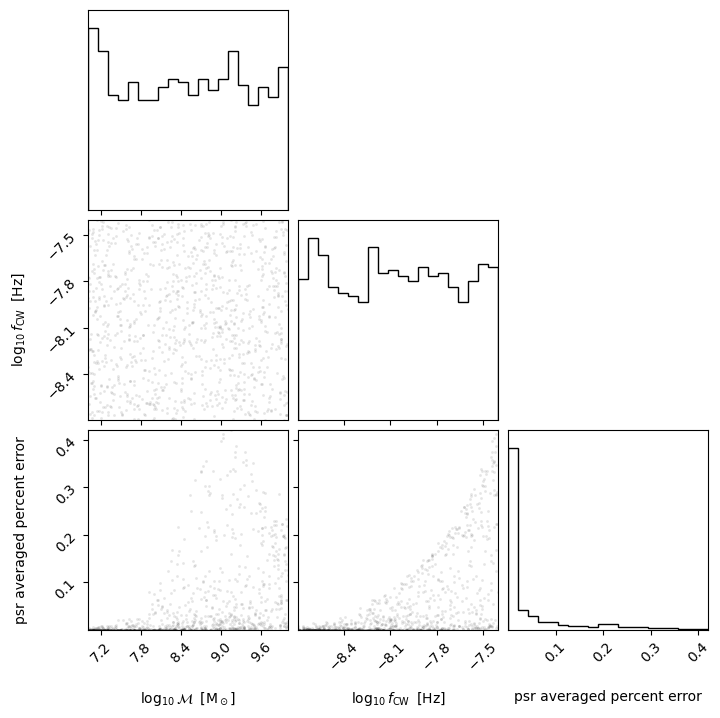

In [10]:
# see where error is largest in parameter space

# average relative error across pulsars
avg_percent_err = np.mean(relative_errors, axis=1) * 100

# put samples into one array
samples = np.array([random_cw_params[:, 0],
                    random_cw_params[:, 1],
                    avg_percent_err]).T

fig = corner.corner(samples,
                    plot_density=False,
                    plot_contours=False,
                    labels=[r'$\log_{10}\mathcal{M}\;\;[\text{M}_\odot]$',
                            r'$\log_{10}f_\text{CW}\;\;[\text{Hz}]$',
                            'psr averaged percent error'])

## Compare Fourier basis CW model with Enterprise

In [12]:
# Fourier design matrix for CW model
# (different than that of stochastic models!)
freqs_det = jnp.arange(1, NG15_data.num_coeff_det // 2 + 1) / NG15_data.Tspan_ext
F_cw = jnp.zeros((toas.shape[1], NG15_data.num_coeff_det))
F_cw = F_cw.at[:, ::2].set(jnp.sin(2.*jnp.pi*freqs_det[None, :]*toas[0][:, None]))
F_cw = F_cw.at[:, 1::2].set(jnp.cos(2.*jnp.pi*freqs_det[None, :]*toas[0][:, None]))

In [13]:
# compute percent error of Fourier model from Enterprise reference
num_evals = 1000

# loop through random samples
Fourier_relative_errors = np.zeros((num_evals, npsrs))
for i in range(num_evals):
    print(f'{np.round(i / num_evals * 100, 3)}%', end='\r')
    ent_cw_delays = get_ent_cw_delay(toas, psrpos, random_cw_params[i],
                                     random_psr_phases[i], random_psr_dists[i])
    # get Fourier coefficients
    a_cw = cw_model.get_coeffs_func(random_cw_params[i], random_psr_phases[i], random_psr_dists[i])
    cw_delays32 = jax.vmap(lambda x, y: jnp.dot(x, y), in_axes=(None, 0))(F_cw, a_cw)
    rel_err = np.sum(np.abs(ent_cw_delays - cw_delays32), axis=1) / np.sum(np.abs(ent_cw_delays), axis=1)
    Fourier_relative_errors[i] = rel_err
Fourier_relative_errors_flat = Fourier_relative_errors.flatten() # flatten across pulsars
print('100.0%')

100.0%


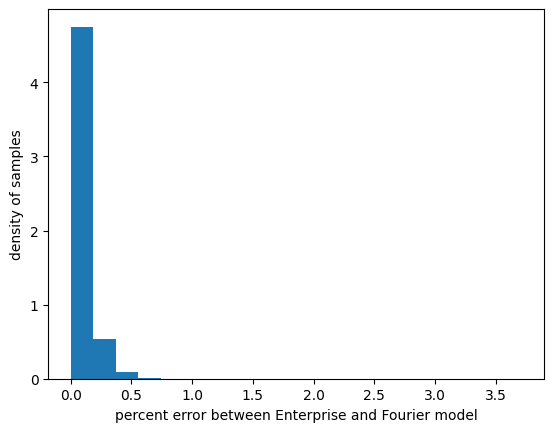

In [14]:
# check distribution of percent errors
Fourier_percent_errors = Fourier_relative_errors_flat * 100
plt.hist(Fourier_percent_errors, density=True, bins=20)
plt.xlabel('percent error between Enterprise and Fourier model')
plt.ylabel('density of samples')
plt.show()

[ 9.89223548e+00 -7.46060098e+00  4.80558266e-01  3.15920776e-01
 -1.61032972e+01  9.98562964e-03  1.12902684e+00  2.15289388e+00]
0.027501692382793815


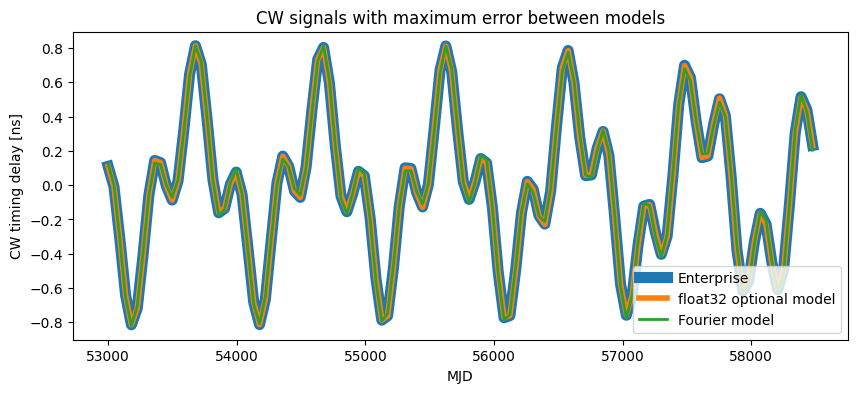

In [32]:
# plot signals with maximum error
max_err_ndx = np.unravel_index(np.nanargmax(Fourier_relative_errors), Fourier_relative_errors.shape)
max_err_sample, max_err_psr = max_err_ndx

max_err_cw_params = random_cw_params[max_err_sample]
max_err_psr_dists = random_psr_dists[max_err_sample]
max_err_psr_phases = random_psr_phases[max_err_sample]
max_err_ent_cw_delay = get_ent_cw_delay(toas, psrpos, max_err_cw_params,
                                        max_err_psr_phases, max_err_psr_dists)[max_err_psr]
max_err_cw_delay32 = cw_model.get_delays_func(toas, psrpos, max_err_cw_params,
                                        max_err_psr_phases, max_err_psr_dists)[max_err_psr]
max_a_cw = cw_model.get_coeffs_func(max_err_cw_params, max_err_psr_phases, max_err_psr_dists)[max_err_psr]
max_err_cw_Fourier = jnp.dot(F_cw, max_a_cw)
print(max_err_cw_params)
print(Fourier_relative_errors[max_err_sample, 5])

plt.figure(figsize=(10, 4))
plt.plot(toas[psr_ndx] / utils.day, max_err_ent_cw_delay, color='C0',
         label='Enterprise', lw=8)
plt.plot(toas[psr_ndx] / utils.day, max_err_cw_delay32, color='C1',
         label='float32 optional model', lw=4)
plt.plot(toas[psr_ndx] / utils.day, max_err_cw_Fourier, color='C2',
         label='Fourier model', lw=2)
plt.legend(loc='lower right')
plt.xlabel('MJD')
plt.ylabel('CW timing delay [ns]')
plt.title('CW signals with maximum error between models')
plt.show()

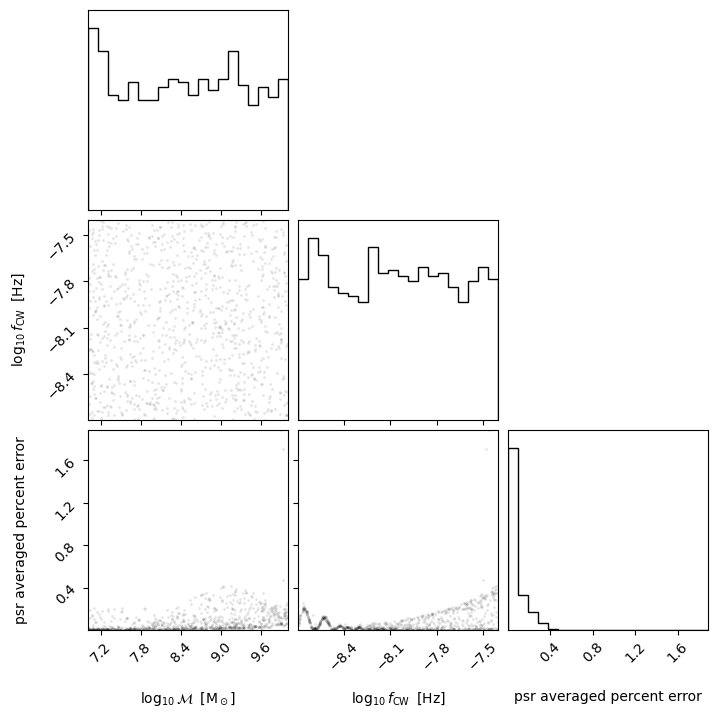

In [46]:
# see where error is largest in parameter space

# average relative error across pulsars
avg_percent_err = np.mean(Fourier_relative_errors, axis=1) * 100
avg_percent_err_fin = avg_percent_err[np.isfinite(avg_percent_err)]
# print(np.any(avg_percent_err))

# put samples into one array
samples = np.array([random_cw_params[np.isfinite(avg_percent_err), 0],
                    random_cw_params[np.isfinite(avg_percent_err), 1],
                    avg_percent_err_fin]).T

fig = corner.corner(samples,
                    plot_density=False,
                    plot_contours=False,
                    labels=[r'$\log_{10}\mathcal{M}\;\;[\text{M}_\odot]$',
                            r'$\log_{10}f_\text{CW}\;\;[\text{Hz}]$',
                            'psr averaged percent error'])